In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

# device agnostic code
device = 'cuda' if torch.cuda.is_available() else 'cpu'


In [13]:
from pathlib import Path
names_path = Path('/content/names.txt')
if not names_path.exists():
    !wget -q https://raw.githubusercontent.com/karpathy/makemore/master/names.txt -O /content/names.txt

In [14]:
# read in all the words

words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [15]:
# build the vocabulary of characters and mapping to/from integers

chars = sorted(list(set(''.join(words)))) 
stoi = {
    s:i+1 for i,s in enumerate(chars)
}
stoi['.'] =0
itos = {
    i:s for s,i in stoi.items()
}

vocab_size = len(stoi)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [16]:
# Building the dataset 

block_size = 3

def build_dataset(words):
    X,Y = [],[]

    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X,Y



In [17]:
# Spliting data into train, dev and test sets

import random
random.seed()

random.shuffle(words)
random.shuffle(words)

n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr , Ytr = build_dataset(words[:n1])
Xdev , Ydev = build_dataset(words[n1:n2])
Xtest , Ytest = build_dataset(words[n2:])


torch.Size([182454, 3]) torch.Size([182454])
torch.Size([22763, 3]) torch.Size([22763])
torch.Size([22929, 3]) torch.Size([22929])


In [18]:
# MLP revisted

n_embd = 10 # the dimensionality of the character embedding words
n_hidden = 200 # the numder fo neurons in the hidden layer of the MLP


g = torch.Generator().manual_seed(2147483647)
c = torch.randn((vocab_size , n_embd), generator=g)


W1 = torch.randn((n_embd * block_size , n_hidden), generator=g) * ((5/3) / ((n_embd* block_size)**0.5))

# no b1: batch norm subtracts the mean, so a bias before BN cancels out; bnbias is the learnable bias after BN

W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.randn(vocab_size, generator=g) * 0 

bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))

bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [c, W1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters))

for p in parameters:
    p.requires_grad = True

12097


In [19]:
W1.shape , W2.shape , b2.shape , bngain.shape , bnbias.shape


(torch.Size([30, 200]),
 torch.Size([200, 27]),
 torch.Size([27]),
 torch.Size([1, 200]),
 torch.Size([1, 200]))

In [20]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,) , generator=g)
    Xb = Xtr[ix]
    Yb = Ytr[ix]
    
    # forward pass
    emb = c[Xb]
    embcat = emb.view(emb.shape[0], -1)

    # linear layer
    hpreact = embcat @ W1

    # Batch Norm layer
    bnmeani = hpreact.mean(0 , keepdim=True)
    bnstdi = hpreact.std(0 , keepdim=True)
    hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias

    with torch.no_grad():
        bnmean_running = bnmean_running * 0.999 + bnmeani * 0.001
        bnstd_running = bnstd_running * 0.999 + bnstdi * 0.001

    # with non-linearity 
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Yb)

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0: # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())


      0/ 200000: 3.2672
  10000/ 200000: 1.8751
  20000/ 200000: 1.9311
  30000/ 200000: 2.2293
  40000/ 200000: 2.6165
  50000/ 200000: 2.2103
  60000/ 200000: 2.5790
  70000/ 200000: 2.5399
  80000/ 200000: 1.8153
  90000/ 200000: 2.0139
 100000/ 200000: 2.3532
 110000/ 200000: 1.8911
 120000/ 200000: 2.0588
 130000/ 200000: 2.1246
 140000/ 200000: 2.2655
 150000/ 200000: 2.1765
 160000/ 200000: 1.6478
 170000/ 200000: 2.2754
 180000/ 200000: 1.9669
 190000/ 200000: 2.1692


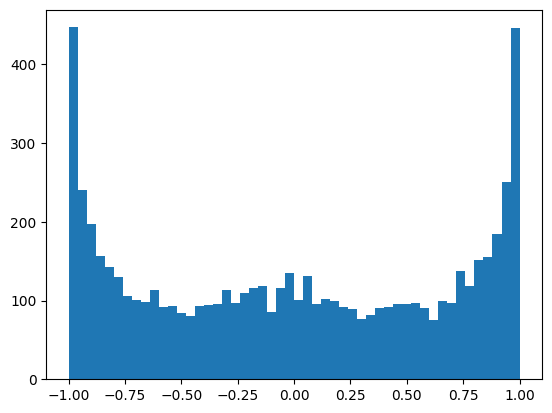

In [21]:
plt.hist(h.view(-1).tolist() , 50);

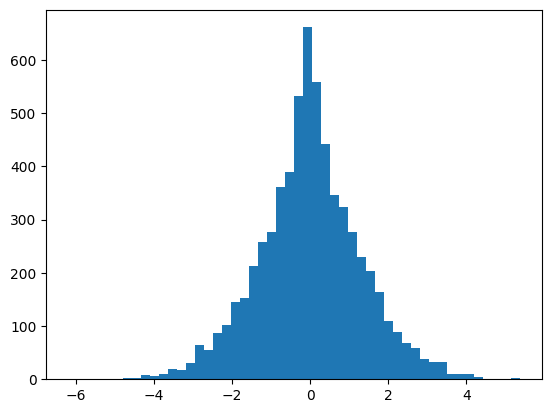

In [22]:
plt.hist(hpreact.view(-1).tolist() , 50);

# Understanding

During the training of our neural network we see the initial loss of our network is too high


In training of neural network we often have a rough idea about what should be the possible loss at initilization that depends on the loss function and the problem setter

## What should be the possible loss at initilization

During initilization we dont have to belive that any other charcter is much more likely than other , we need a uniform distribution 

Assigning equal probality of each characters

Probality of each character is 1/27 = 0.037 

`-torch.tesnor(1/27).log()` = 3.2958


```
    0/ 200000: 25.3398
    10000/ 200000: 3.3337
```


## 2. Issue: Tanh Saturation (Saturated Neurons)

**Tanh** is a squashing function: it maps any real number into the range (-1, 1).

Same setup as in our micrograd chapter:

```
hpreact = embcat @ W1 + b1   # hidden layer pre-activation (linear step)
h = tanh(hpreact)            # hidden layer output (after activation)
```

- `embcat` is the flattened input vector (3 character embeddings concatenated)
- `hpreact[j]` is the weighted sum + bias for hidden neuron `j`, before tanh
- `h` is the output **after** tanh

### What is the problem?

Every `h` is always between -1 and 1 — that is normal. The problem is **saturation at the endpoints**.

With default `torch.randn` init for `W1` and `b1`, each `hpreact` is a sum of ~30 random terms, so values are often large (e.g. ±5, ±10). That pushes `h = tanh(hpreact)` very close to **+1 or -1**, not near 0.

| hpreact (z) | h = tanh(z) | gradient 1 - h² |
|-------------|-------------|-----------------|
| ~0          | ~0          | ~1 (healthy)    |
| +5          | ~0.999      | ~0.002 (tiny)   |
| -8          | ~-1.0       | ~0 (saturated)  |

The histograms above show this: `hpreact` is spread out widely, while `h` piles up near ±1.

### Backprop through tanh (same as micrograd)

```
hpreact.grad = (1 - h²) * h.grad
```

When saturated, `h ≈ ±1`:

```
1 - h² ≈ 1 - 1 = 0
→ hpreact.grad ≈ 0 * h.grad = 0
```

So the upstream gradient gets multiplied by nearly zero — learning through those hidden units is blocked at initialization.

**Fix (weight scaling):** scale down `W1` and `b1` so `hpreact` stays roughly in `[-1, 1]` and `h` stays near 0 at init.

---

## 3. Batch Normalization

We don't want `hpreact` to be too small or too large:

- **Too small** → tanh is in its linear region but neurons barely do anything
- **Too large** → tanh saturates near ±1 and gradients vanish

We want `hpreact` in a **consistent, controlled range** before tanh — ideally ~standard normal (mean 0, std 1).

Batch norm does this per hidden unit, using statistics from the current minibatch:

```
bnmeani = hpreact.mean(0, keepdim=True)   # mean across batch, per neuron
bnstdi  = hpreact.std(0, keepdim=True)    # std across batch, per neuron
hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias
h = tanh(hpreact)
```

- Subtract mean → centers activations around 0
- Divide by std → controls spread (prevents huge values)
- `bngain`, `bnbias` → learnable scale/shift (lets the network undo normalization if needed)

We also track **running** mean/std (`bnmean_running`, `bnstd_running`) with an exponential moving average for inference later.

**Intuition:** batch norm acts like a thermostat on `hpreact` — keeps it in a healthy zone so tanh doesn't saturate and gradients can flow.

### Clarifying a common question: Gaussian activations and "diverse" learning

**Does batch norm force every batch to look the same?**

Not exactly. There are two stages to keep straight:

- **Raw `hpreact`** (before batch norm): can still vary a lot from batch to batch.
- **After batch norm**: activations are pushed toward a stable distribution (~mean 0, std 1) **for that batch**.

That normalization is intentional. We *do* want a consistent, healthy range going into tanh. The goal is not "make every batch identical forever" — it is "keep what reaches tanh in a good zone so gradients can flow."

**What are `bngain` and `bnbias` really for?**

They are not mainly there to make learning "more diverse." They are learnable knobs that let each neuron adjust normalization if it needs to:

- `bngain > 1` → scale up after normalization
- `bngain < 1` → scale down
- `bnbias` → shift up or down

So the network is not locked to exactly N(0,1) forever. Each neuron can learn its own preferred scale and offset **after** normalization.

**Where does diversity actually come from?**

- Different minibatches have different means/stds, so normalization changes slightly each step. That adds a bit of noise and acts like mild regularization.
- The layer below batch norm can still learn rich representations. Batch norm just makes sure the values hitting tanh stay in a healthy range.

**One-line takeaway:** batch norm is less about forcing diversity and more about keeping activations in a healthy range so tanh does not saturate — while still letting the network learn how much to scale or shift each neuron.


In [23]:
torch.tensor(1/27).log()

tensor(-3.2958)

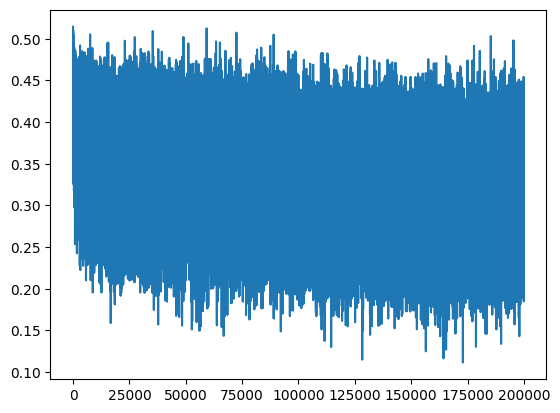

In [24]:
plt.plot(lossi)

In [25]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        "train": (Xtr, Ytr),
        "dev": (Xdev, Ydev),
        "test": (Xtest, Ytest)
    }[split]
    emb = c[x]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1
    hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(f"{split}: {loss.item():.4f}")

split_loss("train")
split_loss("dev")
split_loss("test")

train: 2.0666
dev: 2.1112
test: 2.1155


# Optimization results

1. The network is too confident in the start  

```
    train: 2.1369
    dev: 2.1534
    test: 2.1897

```

2. Correctly configure the network at initlization
```
    train: 2.0719
    dev: 2.1133
    test: 2.1470
```

3. Fixing the tanh saturation

```
    train: 2.0380
    dev: 2.1110
    test: 2.1131
```

4. Batch normalization
```
    train: 2.0666
    dev: 2.1112
    test: 2.1155
```

In [26]:
# sample from the model

g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        # forward pass the neural net
        emb = c[torch.tensor([context])] # (1, block_size, n_embd)
        hpreact = emb.view(1, -1) @ W1
        hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
        h = torch.tanh(hpreact)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        # sample from the distribution
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        # shift the context window and track the samples
        context = context[1:] + [ix]
        out.append(ix)
        # if we sample the special '.' token, break
        if ix == 0:
            break
    print(''.join(itos[i] for i in out))

carmahzaal.
hari.
kimri.
reviyah.
cassie.
rah.
bradelynn.
jarqui.
nellara.
chaiiv.
kaleigh.
ham.
jois.
quint.
shourta.
jadiq.
watell.
dearyn.
kai.
eveigh.
